# Engineering Student Productivity Dashboard

A Data Science project that analyzes an engineering student's daily productivity using study habits, coding practice, sleep patterns, exercise, and mood tracking.

This project demonstrates:
- Data Cleaning with Pandas
- Data Analysis
- Productivity Score Calculation
- Data Visualization using Matplotlib
- Data Visualization using Seaborn

## Project Objective

The objective of this project is to analyze daily productivity patterns of an engineering student and identify factors that influence productivity.

The project aims to:

- Track study and coding hours
- Analyze sleep and exercise habits
- Measure mood and productivity levels
- Generate meaningful insights through visualizations
- Build a beginner-friendly Data Science dashboard project

## Dataset Features

The dataset contains the following columns:

| Column Name | Description |
|------------|-------------|
| Date | Date of observation |
| Study_Hours | Hours spent studying |
| Python_Hours | Hours spent practicing Python |
| College_Hours | Hours spent attending college |
| Sleep_Hours | Hours of sleep |
| Exercise_Minutes | Minutes spent exercising |
| Mood_Score | Daily mood score (1-10) |

## Import Libraries

The following libraries are required for data analysis and visualization.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [11]:
df = pd.read_csv("datasets/productivity_data.csv")

df.head()

,Date,Study_Hours,Python_Hours,College_Hours,Sleep_Hours,Exercise_Minutes,Mood_Score
0,2026-06-01,3,1,6,7,30,8
1,2026-06-02,4,2,5,8,20,7
2,2026-06-03,2,1,6,6,15,6
3,2026-06-04,5,2,5,8,40,9
4,2026-06-05,3,1,6,7,25,7


## Dataset Overview

Explore the dataset structure and basic information.

In [12]:
df.shape

(10, 7)

In [13]:
df.columns

Index(['Date', 'Study_Hours', 'Python_Hours', 'College_Hours', 'Sleep_Hours',
       'Exercise_Minutes', 'Mood_Score'],
      dtype='str')

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Date              10 non-null     str  
 1   Study_Hours       10 non-null     int64
 2   Python_Hours      10 non-null     int64
 3   College_Hours     10 non-null     int64
 4   Sleep_Hours       10 non-null     int64
 5   Exercise_Minutes  10 non-null     int64
 6   Mood_Score        10 non-null     int64
dtypes: int64(6), str(1)
memory usage: 692.0 bytes


In [15]:
df.describe()

,Study_Hours,Python_Hours,College_Hours,Sleep_Hours,Exercise_Minutes,Mood_Score
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,3.500000,1.600000,5.600000,7.200000,27.000000,7.500000
std,1.080123,0.699206,0.516398,0.788811,11.105554,1.080123
min,2.000000,1.000000,5.000000,6.000000,10.000000,6.000000
25%,3.000000,1.000000,5.000000,7.000000,20.000000,7.000000
50%,3.500000,1.500000,6.000000,7.000000,27.500000,7.500000
75%,4.000000,2.000000,6.000000,8.000000,33.750000,8.000000
max,5.000000,3.000000,6.000000,8.000000,45.000000,9.000000


## Data Cleaning

In this section, we check for missing values, duplicate records, and ensure that the dataset is properly formatted for analysis.

### Check Missing Values

In [16]:
df.isnull().sum()

Date                0
Study_Hours         0
Python_Hours        0
College_Hours       0
Sleep_Hours         0
Exercise_Minutes    0
Mood_Score          0
dtype: int64

### Check Duplicate Rows

In [17]:
df.duplicated().sum()

np.int64(0)

### Convert Date Column to Datetime Format

In [18]:
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Study_Hours,Python_Hours,College_Hours,Sleep_Hours,Exercise_Minutes,Mood_Score
0,2026-06-01,3,1,6,7,30,8
1,2026-06-02,4,2,5,8,20,7
2,2026-06-03,2,1,6,6,15,6
3,2026-06-04,5,2,5,8,40,9
4,2026-06-05,3,1,6,7,25,7


### Verify Data Types

In [19]:
df.dtypes

Date                datetime64[us]
Study_Hours                  int64
Python_Hours                 int64
College_Hours                int64
Sleep_Hours                  int64
Exercise_Minutes             int64
Mood_Score                   int64
dtype: object

### Data Cleaning Summary

- No missing values found.
- No duplicate records found.
- Date column converted to datetime format.
- Dataset is clean and ready for analysis.

## Productivity Score Calculation

To measure overall daily productivity, we create a custom Productivity Score using study hours, Python practice, exercise, and mood.

Formula:

Productivity Score =
(Study_Hours × 3)
+ (Python_Hours × 4)
+ (Exercise_Minutes ÷ 10)
+ Mood_Score

In [20]:
df["Productivity_Score"] = (
    df["Study_Hours"] * 3
    + df["Python_Hours"] * 4
    + df["Exercise_Minutes"] / 10
    + df["Mood_Score"]
)

df.head()

,Date,Study_Hours,Python_Hours,College_Hours,Sleep_Hours,Exercise_Minutes,Mood_Score,Productivity_Score
0,2026-06-01,3,1,6,7,30,8,24.0
1,2026-06-02,4,2,5,8,20,7,29.0
2,2026-06-03,2,1,6,6,15,6,17.5
3,2026-06-04,5,2,5,8,40,9,36.0
4,2026-06-05,3,1,6,7,25,7,22.5


### View Productivity Scores

In [21]:
df[["Date", "Productivity_Score"]]

,Date,Productivity_Score
0,2026-06-01,24.0
1,2026-06-02,29.0
2,2026-06-03,17.5
3,2026-06-04,36.0
4,2026-06-05,22.5
5,2026-06-06,31.0
6,2026-06-07,40.5
7,2026-06-08,22.0
8,2026-06-09,31.5
9,2026-06-10,17.0


### Productivity Score Statistics

In [22]:
df["Productivity_Score"].describe()

count    10.000000
mean     27.100000
std       7.802421
min      17.000000
25%      22.125000
50%      26.500000
75%      31.375000
max      40.500000
Name: Productivity_Score, dtype: float64

### Highest Productivity Day

In [23]:
df.loc[df["Productivity_Score"].idxmax()]

Date                  2026-06-07 00:00:00
Study_Hours                             5
Python_Hours                            3
College_Hours                           5
Sleep_Hours                             7
Exercise_Minutes                       45
Mood_Score                              9
Productivity_Score                   40.5
Name: 6, dtype: object

### Lowest Productivity Day

In [24]:
df.loc[df["Productivity_Score"].idxmin()]

Date                  2026-06-10 00:00:00
Study_Hours                             2
Python_Hours                            1
College_Hours                           6
Sleep_Hours                             6
Exercise_Minutes                       10
Mood_Score                              6
Productivity_Score                   17.0
Name: 9, dtype: object

### Productivity Score Summary

A custom productivity score was calculated using study hours, Python practice, exercise, and mood.

This score helps identify highly productive and less productive days and will be used in further visualizations.

## Data Visualization using Matplotlib

In this section, we visualize student productivity patterns using different types of charts.

### Line Plot : Productivity Score Trend Over Time

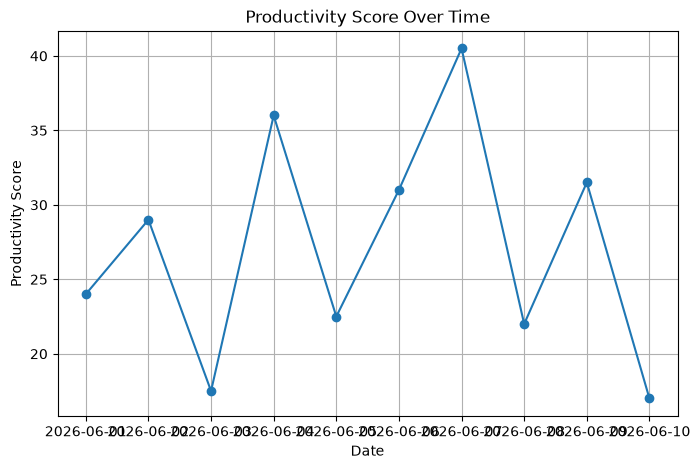

In [25]:
plt.figure(figsize=(8,5))

plt.plot(df["Date"], df["Productivity_Score"], marker="o")

plt.title("Productivity Score Over Time")
plt.xlabel("Date")
plt.ylabel("Productivity Score")
plt.grid(True)

plt.show()

### Scatter Plot : Study Hours vs Productivity Score

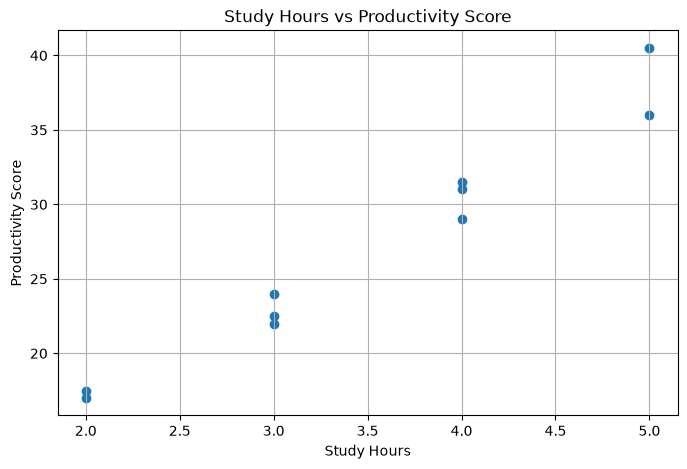

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(df["Study_Hours"], df["Productivity_Score"])

plt.title("Study Hours vs Productivity Score")
plt.xlabel("Study Hours")
plt.ylabel("Productivity Score")
plt.grid(True)

plt.show()

### Bar Chart : Daily Study Hours

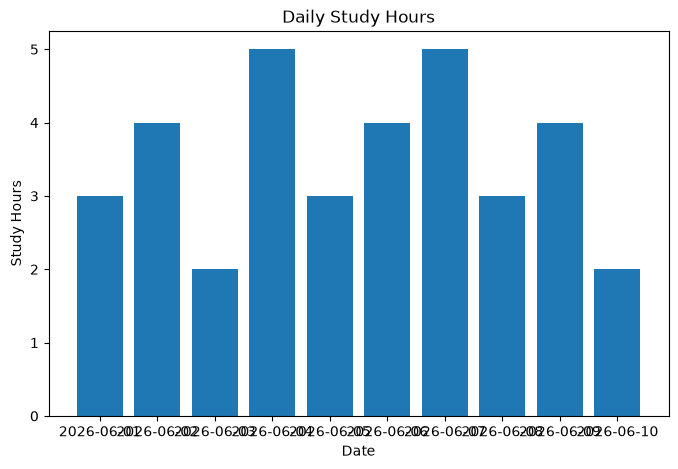

In [27]:
plt.figure(figsize=(8,5))

plt.bar(df["Date"], df["Study_Hours"])

plt.title("Daily Study Hours")
plt.xlabel("Date")
plt.ylabel("Study Hours")

plt.show()

### Histogram : Sleep Hours Distribution

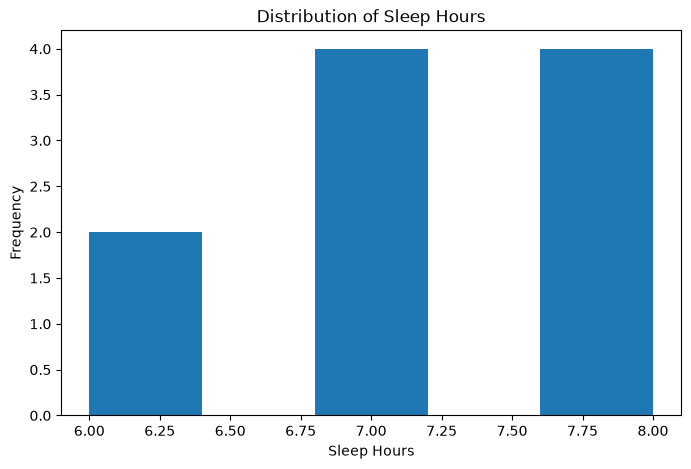

In [28]:
plt.figure(figsize=(8,5))

plt.hist(df["Sleep_Hours"], bins=5)

plt.title("Distribution of Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Frequency")

plt.show()

### Pie Chart : Average Time Allocation

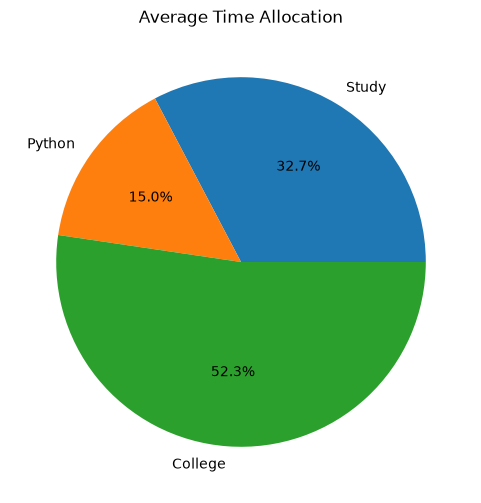

In [29]:
time_data = [
    df["Study_Hours"].mean(),
    df["Python_Hours"].mean(),
    df["College_Hours"].mean()
]

labels = ["Study", "Python", "College"]

plt.figure(figsize=(6,6))

plt.pie(time_data, labels=labels, autopct="%1.1f%%")

plt.title("Average Time Allocation")

plt.show()

## Matplotlib Visualization Summary

- Productivity score generally increased on days with higher study and Python practice hours.
- Students who studied more tended to have higher productivity scores.
- Sleep duration was mostly between 6 and 8 hours.
- College activities occupied a significant portion of daily time.
- Visualizations helped identify productivity trends and patterns.

# Data Visualization using Seaborn

## Correlation Heatmap

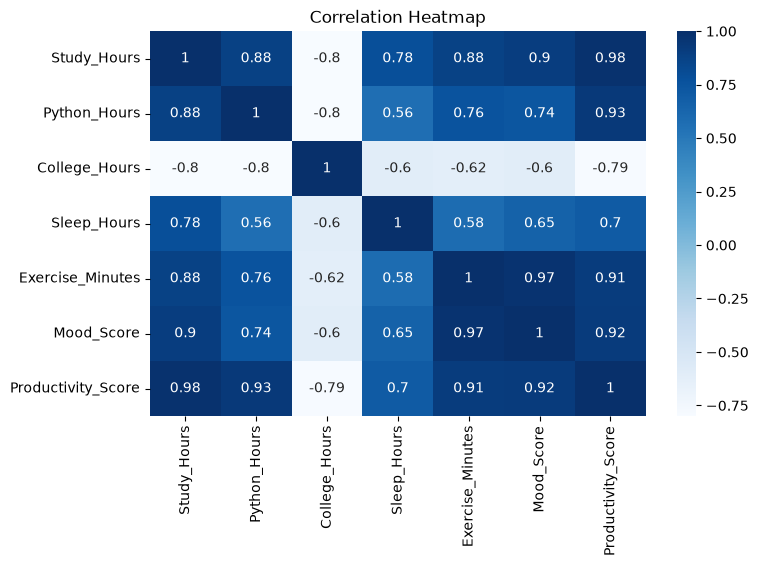

In [30]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="Blues")

plt.title("Correlation Heatmap")
plt.show()

## Pairplot Analysis

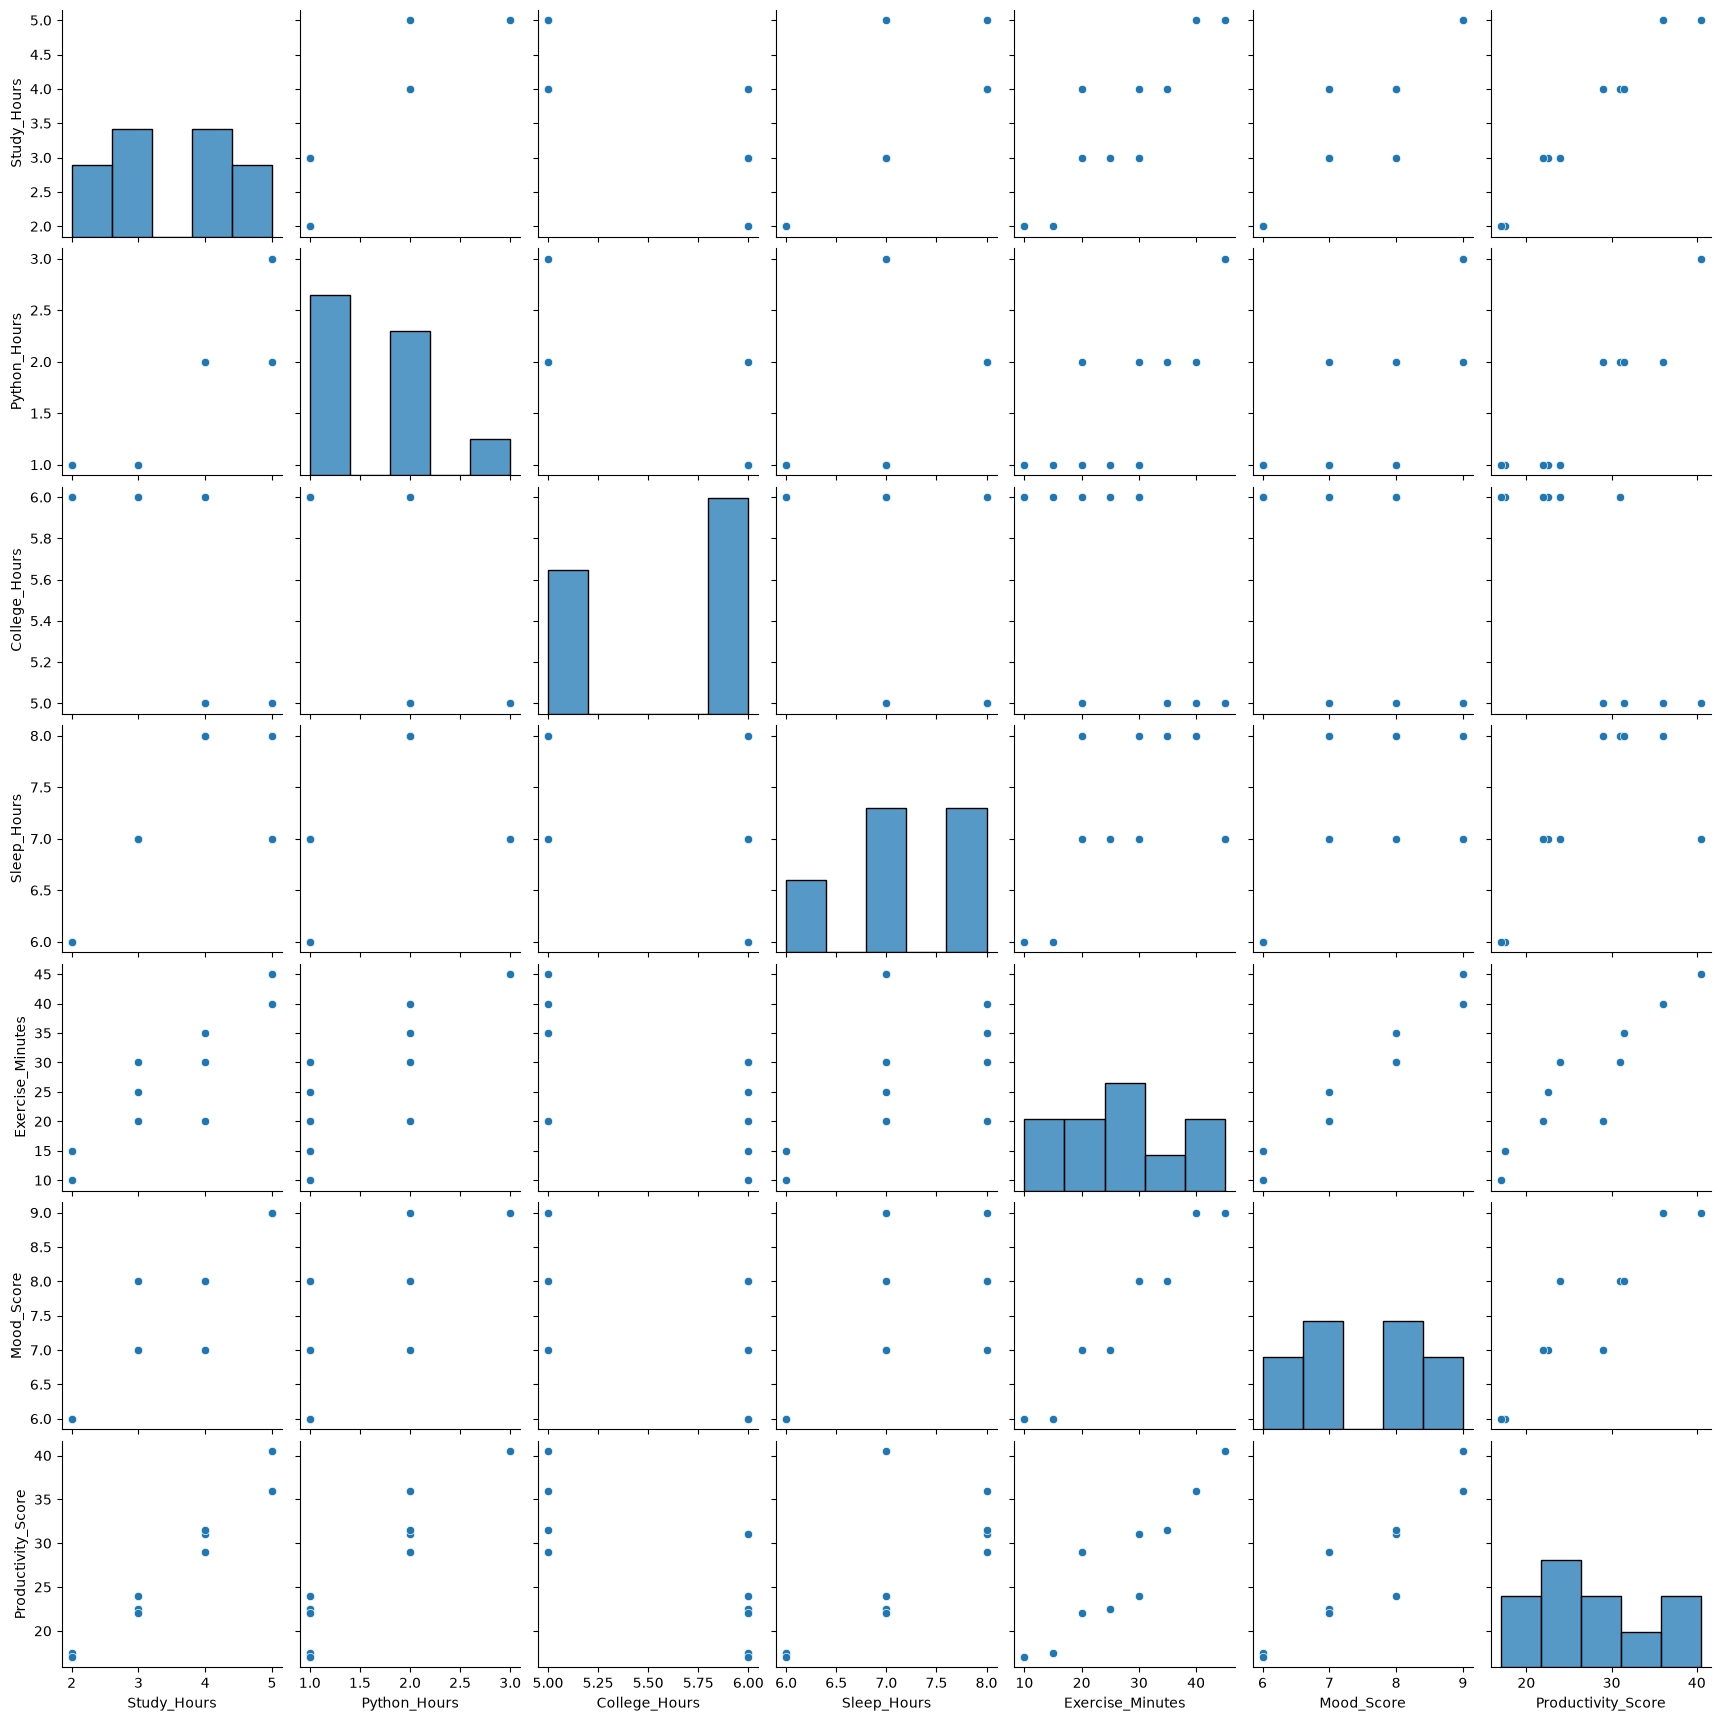

In [31]:
sns.pairplot(df)

plt.show()

## Boxplot of Study Hours

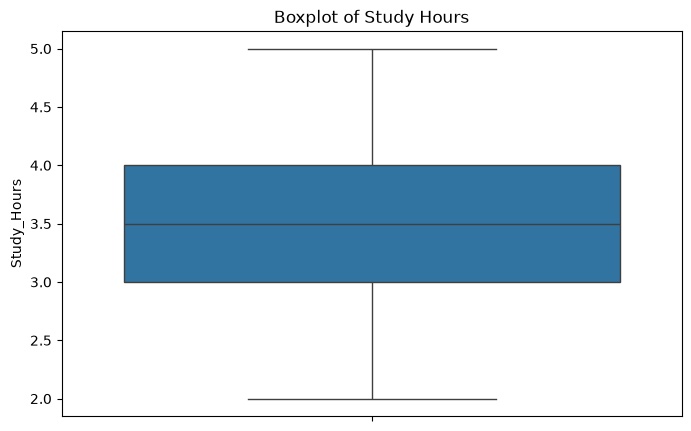

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Study_Hours"])

plt.title("Boxplot of Study Hours")

plt.show()

## Distribution of Productivity Score

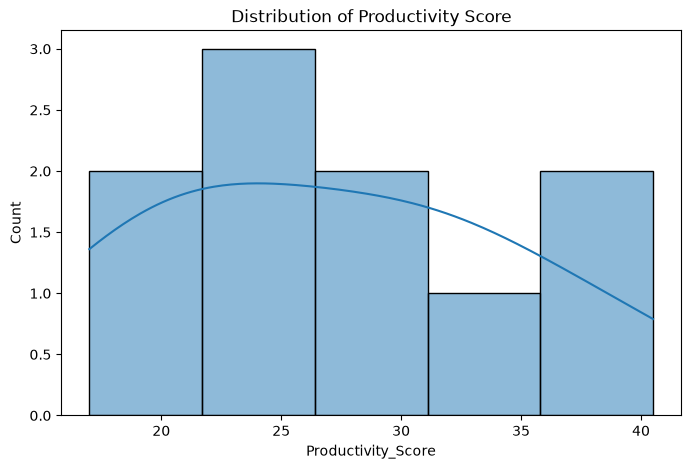

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df["Productivity_Score"], kde=True)

plt.title("Distribution of Productivity Score")

plt.show()

In [34]:
df["Productivity_Level"] = [
    "High" if x > 25 else "Low"
    for x in df["Productivity_Score"]
]

## Countplot of Productivity Levels

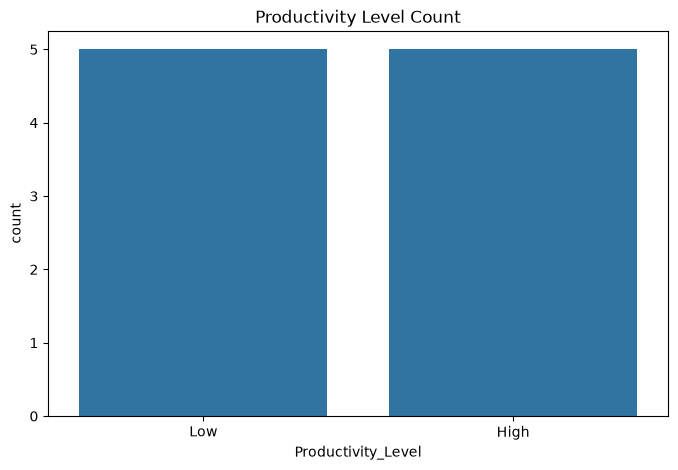

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(x="Productivity_Level", data=df)

plt.title("Productivity Level Count")

plt.show()

# Project Findings

## Key Findings
- Higher study hours generally resulted in higher productivity scores.
- Python practice contributed positively to overall productivity.
- Students with balanced sleep schedules showed better mood scores.
- Exercise helped maintain consistent productivity levels.
- Productivity trends can be effectively analyzed using data visualization techniques.

# Project Conclusion

This project demonstrates how Data Science can be used to analyze and visualize student productivity patterns.

Using Pandas, the dataset was cleaned and analyzed. Matplotlib and Seaborn were used to create meaningful visualizations that helped identify relationships between study habits, sleep, exercise, and productivity.

The project provides a simple example of an end-to-end Data Science workflow including data collection, cleaning, analysis, visualization, and reporting.

# Future Improvements

## Future Scope

- Collect data for multiple students.
- Increase dataset size for deeper analysis.
- Build interactive dashboards using Streamlit.
- Apply Machine Learning models to predict productivity.
- Deploy the project as a web application.

# Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook
- VS Code

# Project Status

✅ Completed Successfully

This project is part of my Python for Data Science learning journey and demonstrates practical application of Data Analysis and Data Visualization concepts.